## Composite 

### Import package

In [8]:
import os
import sys

import numpy as np
import netCDF4 as nc

from pathlib import Path
from datetime import datetime
from scipy.ndimage import convolve1d
from matplotlib import pyplot as plt
from matplotlib.colors import TwoSlopeNorm
sys.path.append("/home/b11209013/Manuscript_Prep/KW_CRI/src")
import spectrum

### Helper Functions

In [9]:
def convert_time(time_variable: nc.Variable) -> np.ndarray:
    """Return a netCDF time coordinate as YYYY-MM-DD strings."""
    dates = nc.num2date(
        time_variable[:],
        units=time_variable.units,
        calendar=getattr(time_variable, "calendar", "standard"),
    )
    dates_array = np.asarray(dates).ravel()
    return np.asarray(
        [date.strftime("%Y-%m-%d") for date in dates_array],
        dtype=str,
    )

def as_float_array(values: np.ndarray) -> np.ndarray:
    """Convert a netCDF array to float and replace masked values by NaN."""
    masked_values = np.ma.asarray(values, dtype=np.float32)
    return np.asarray(masked_values.filled(np.nan))

### Identifying the KW

#### Load OLR

In [10]:
START_DATE = datetime(2006, 1, 1).strftime("%Y-%m-%d")
END_DATE = datetime(2018, 1, 1).strftime("%Y-%m-%d")
LATITUDE_BOUNDS = (-5.0, 5.0)

with nc.Dataset("/work/DATA/Satellite/OLR/olr_anomaly.nc", "r") as olr_ds:
    all_olr_dates: np.ndarray = convert_time(olr_ds.variables["time"])
    olr_lat  : np.ndarray = as_float_array(olr_ds.variables["lat"][...])
    olr_lon  : np.ndarray = as_float_array(olr_ds.variables["lon"][...])

    time_mask = (all_olr_dates >= START_DATE) & (all_olr_dates < END_DATE)
    lat_mask  = (olr_lat >= LATITUDE_BOUNDS[0]) & (olr_lat <= LATITUDE_BOUNDS[1])

    olr      : np.ndarray = as_float_array(
        olr_ds.variables["olr"][
            time_mask, lat_mask, :
        ]
    )
    olr_dates: np.ndarray = all_olr_dates[time_mask]

olr_nt, olr_ny, olr_nx = olr.shape

#### Preprocessing

In [11]:
# remove time and zonal mean
olr_anom: np.ndarray = olr - np.nanmean(olr, axis=(0, -1), keepdims=True)

# symmetrizing data
olr_symm: np.ndarray = spectrum.symm_asym(olr_anom, lat_axis=1)[0].mean(axis=1)

#### Transform

In [12]:
# set wavenumber and frequency
wnum: np.ndarray = np.fft.fftfreq(olr_nx, d=1/olr_nx)
freq: np.ndarray = np.fft.fftfreq(olr_nt, d=1)

wnums, freqs = np.meshgrid(wnum, freq)

# FFT transform
olr_fft: np.ndarray = np.fft.fft(np.fft.ifft(olr_symm, axis=0), axis=1)

# apply masking
def kelvin_disprel(
        edep: float,
        wnum: np.ndarray
) -> np.ndarray:

    return np.sqrt(9.81 * edep) * 86400.0 / (2*np.pi*6.371e6) * wnum

wnum_lim = ((wnums >= 3) & (wnums <= 8)) | ((wnums <= -3) & (wnums >= -8))
freq_lim = ((freqs >= 1/20) & (freqs <= 1/2.5)) | ((freqs <= -1/20) & (freqs >= -1/2.5))
edep_lim = (freqs >= kelvin_disprel(8, wnums)) & (freqs <= kelvin_disprel(90, wnums)) | \
    (freqs <= kelvin_disprel(8, wnums)) & (freqs >= kelvin_disprel(90, wnums))

mask = wnum_lim & freq_lim & edep_lim

olr_mask = np.where(mask, olr_fft, 0.0)

# IFFT transform
Kelvin_recon: np.ndarray = np.fft.ifft(np.fft.fft(olr_mask, axis=0), axis=1).real


#### Select significant events

In [13]:
# Calculate statistics
mean: float = Kelvin_recon.flatten().mean()
std : float = Kelvin_recon.flatten().std()

criteria: float = mean - 2.96 * std

Kelvin_significant = np.where(Kelvin_recon <= criteria)

time_idx = Kelvin_significant[0]
lon_idx  = Kelvin_significant[1]

lon_val: np.ndarray = np.array([
    olr_lon[l] for l in lon_idx
])

### Composite

#### Load ERA5 Dataset

In [14]:
ERA5_W_PATH = "/data92/b11209013/ERA5_GRIB/Data/tropical_-10_10/w.nc"
ERA5_T_PATH = "/data92/b11209013/ERA5_GRIB/Data/tropical_-10_10/T.nc"
ERA5_Q_PATH = "/data92/b11209013/ERA5_GRIB/Data/tropical_-10_10/Q.nc"
CLOUDSAT_QR_PATH = "/data92/b11209013/CloudSat/DATA/QR_gridded_15layer_-5_5.nc"

event_dates = olr_dates[np.asarray(time_idx, dtype=np.intp)]
if event_dates.size == 0:
    raise ValueError("No significant Kelvin-wave events were detected.")
unique_event_dates, event_loaded_time_idx = np.unique(
    event_dates, return_inverse=True
)

def dataset_date_strings(time_variable: nc.Variable) -> np.ndarray:
    """Convert conventional CF time or CDO YYYYMMDD time to date strings."""
    units = str(getattr(time_variable, "units", ""))
    if units.startswith("day as %Y%m%d"):
        values = np.asarray(
            np.ma.asarray(time_variable[...], dtype=np.float64).filled(np.nan)
        ).ravel()
        return np.asarray(
            [datetime.strptime(str(int(value)), "%Y%m%d").strftime("%Y-%m-%d")
             for value in values],
            dtype=str,
        )
    return convert_time(time_variable)

def load_event_latitude_mean(
    path: str,
    variable_name: str,
    selected_dates: np.ndarray,
    latitude_bounds: tuple[float, float] = LATITUDE_BOUNDS,
    batch_size: int = 32,
) -> tuple[np.ndarray, dict[str, np.ndarray]]:
    """Load unique event days, then average over the latitude band."""
    with nc.Dataset(path, "r") as ds:
        variable = ds[variable_name]
        if variable.ndim != 4 or variable.dimensions[0] != "time":
            raise ValueError(
                f"{variable_name} must have dimensions (time, level, lat, lon); "
                f"got {variable.dimensions}."
            )

        _, level_name, lat_name, lon_name = variable.dimensions
        source_dates = dataset_date_strings(ds["time"])
        selected_times = np.searchsorted(source_dates, selected_dates)
        found = selected_times < source_dates.size
        found[found] &= source_dates[selected_times[found]] == selected_dates[found]
        if not np.all(found):
            missing = ", ".join(selected_dates[~found][:5])
            raise ValueError(f"Event dates are missing from {path}: {missing}")

        latitude = as_float_array(ds[lat_name][...])
        lat_indices = np.flatnonzero(
            (latitude >= latitude_bounds[0])
            & (latitude <= latitude_bounds[1])
        )
        if lat_indices.size == 0:
            raise ValueError(f"No requested latitudes are present in {path}.")
        lat_slice = slice(lat_indices[0], lat_indices[-1] + 1)

        result = np.empty(
            (selected_times.size, variable.shape[1], variable.shape[-1]),
            dtype=np.float32,
        )
        for start in range(0, selected_times.size, batch_size):
            stop = min(start + batch_size, selected_times.size)
            block = as_float_array(
                variable[selected_times[start:stop], :, lat_slice, :]
            )
            valid_count = np.isfinite(block).sum(axis=2)
            result[start:stop] = np.divide(
                np.nansum(block, axis=2, dtype=np.float64),
                valid_count,
                out=np.full(valid_count.shape, np.nan, dtype=np.float64),
                where=valid_count > 0,
            )

        coordinates = {
            "level": as_float_array(ds[level_name][...]),
            "lon": as_float_array(ds[lon_name][...]),
        }
    return result, coordinates

w, w_coords = load_event_latitude_mean(ERA5_W_PATH, "w", unique_event_dates)
t, t_coords = load_event_latitude_mean(ERA5_T_PATH, "T", unique_event_dates)
q, q_coords = load_event_latitude_mean(ERA5_Q_PATH, "Q", unique_event_dates)
lw, lw_coords = load_event_latitude_mean(
    CLOUDSAT_QR_PATH, "QLW", unique_event_dates
)
sw, sw_coords = load_event_latitude_mean(
    CLOUDSAT_QR_PATH, "QSW", unique_event_dates
)

for name, coordinates in (
    ("T", t_coords), ("Q", q_coords),
    ("QLW", lw_coords), ("QSW", sw_coords),
):
    if not (
        np.allclose(coordinates["level"], w_coords["level"])
        and np.allclose(coordinates["lon"], w_coords["lon"])
    ):
        raise ValueError(f"{name} does not use the same level/longitude grid as w.")

N_EVENT_DAYS, N_LEVELS, N_LONGITUDES = w.shape
print(
    f"Loaded {N_EVENT_DAYS} unique event days for "
    f"{event_dates.size} event points."
)

Loaded 591 unique event days for 11061 event points.


#### Preprocessing

In [15]:
# Remove the unique event-day and zonal mean in place. For an all-day
# climatological baseline, load a separately precomputed climatology here.
for field in (w, t, q, lw, sw):
    field -= np.nanmean(field, axis=(0, -1), keepdims=True)

# Pair every event with its position on the compact loaded time axis.
event_time_idx = np.asarray(event_loaded_time_idx, dtype=np.intp)
if event_time_idx.size != lon_val.size:
    raise ValueError("Event time and longitude arrays have different lengths.")

field_lon = np.asarray(w_coords["lon"])
lon_spacing = 360.0 / N_LONGITUDES
if not np.allclose(np.diff(field_lon), lon_spacing):
    raise ValueError("Expected a regular, increasing ERA5 longitude grid.")
event_lon_idx = (
    np.rint(((lon_val - field_lon[0]) % 360.0) / lon_spacing).astype(np.intp)
    % N_LONGITUDES
)
event_shifts = N_LONGITUDES // 2 - event_lon_idx

def event_centered_composite(
    field: np.ndarray,
    event_times: np.ndarray,
    shifts: np.ndarray,
    batch_size: int = 256,
) -> np.ndarray:
    """Average event snapshots after centering them in longitude."""
    total = np.zeros(field.shape[1:], dtype=np.float64)
    valid_count = np.zeros(field.shape[1:], dtype=np.int64)
    target_lon = np.arange(field.shape[-1])

    for start in range(0, event_times.size, batch_size):
        stop = min(start + batch_size, event_times.size)
        batch = field[event_times[start:stop]]
        source_lon = (
            target_lon[None, :] - shifts[start:stop, None]
        ) % field.shape[-1]
        centered = np.take_along_axis(
            batch, source_lon[:, None, :], axis=-1
        )
        valid = np.isfinite(centered)
        total += np.nansum(centered, axis=0, dtype=np.float64)
        valid_count += valid.sum(axis=0)

    return np.divide(
        total,
        valid_count,
        out=np.full_like(total, np.nan),
        where=valid_count > 0,
    )

w_composite = event_centered_composite(w, event_time_idx, event_shifts)
t_composite = event_centered_composite(t, event_time_idx, event_shifts)
q_composite = event_centered_composite(q, event_time_idx, event_shifts)
lw_composite = event_centered_composite(lw, event_time_idx, event_shifts)
sw_composite = event_centered_composite(sw, event_time_idx, event_shifts)

print(w_composite.shape)

(15, 1440)


In [16]:
COMPOSITE_OUTPUT_DIR = Path("/home/b11209013/KW_CloudSat/Files/ERA5_GRIB")
COMPOSITE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
for name, composite in {
    "w": w_composite,
    "T": t_composite,
    "Q": q_composite,
    "LW": lw_composite,
    "SW": sw_composite,
}.items():
    np.savetxt(COMPOSITE_OUTPUT_DIR / f"{name}_composite.txt", composite)

In [17]:
# Smooth the radiative-heating composites over 10 degrees longitude.
smoothing_kernel = np.ones(40) / 40
lw_smoothed = convolve1d(lw_composite, smoothing_kernel, axis=1, mode="wrap")
sw_smoothed = convolve1d(sw_composite, smoothing_kernel, axis=1, mode="wrap")

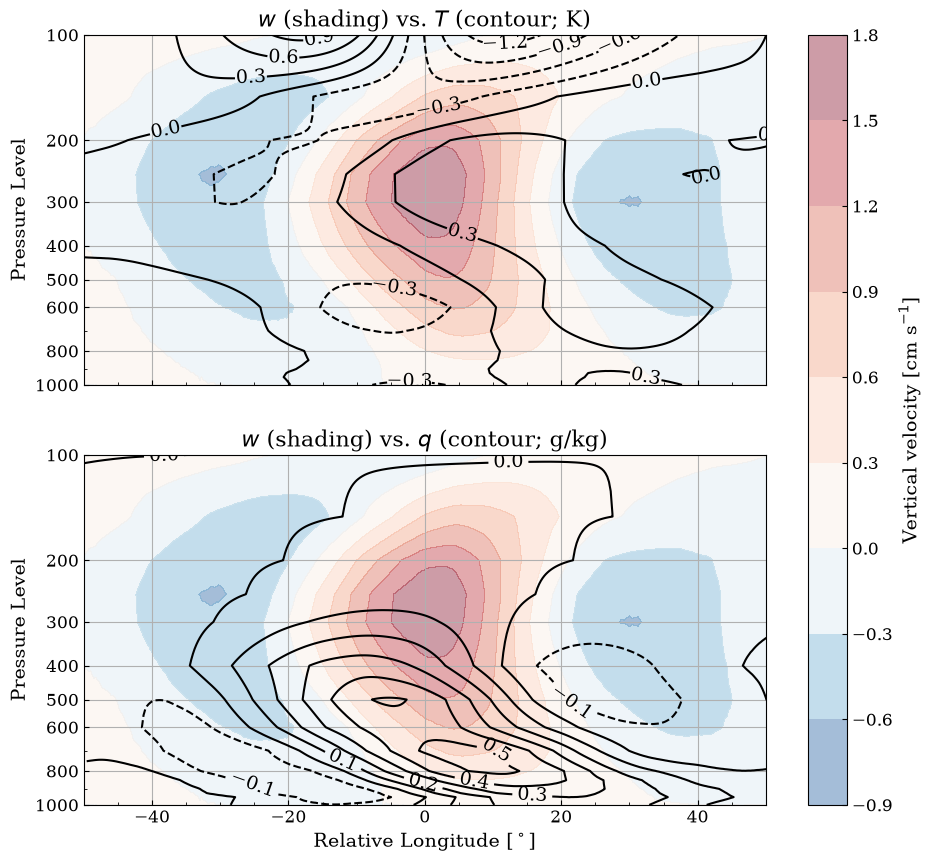

In [18]:
x_rel: np.ndarray = (np.arange(N_LONGITUDES) - N_LONGITUDES // 2) * lon_spacing
plev: np.ndarray = w_coords["level"] / 100.0

# general figure configuration
plt.rcParams.update(
    {
        "font.family": "serif",
        "font.size": 14,
        "axes.labelsize": 14,
        "axes.titlesize": 16,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "legend.fontsize": 12,
        "figure.titlesize": 18,
    }
)


fig, axes = plt.subplots(2, 1, figsize=(11, 10), sharex="col")

ax1, ax2 = axes.flatten()

w_ctf = ax1.contourf(
    x_rel, plev,
    (w_composite - np.nanmean(w_composite, axis=1, keepdims=True)) * 1e2,
    cmap="RdBu_r",
    norm = TwoSlopeNorm(0.0),
    alpha=0.4
    )
T_ct = ax1.contour(
    x_rel, plev,
    t_composite - np.nanmean(t_composite, axis=1, keepdims=True),
    colors="k"
    )
ax1.minorticks_on()
ax1.set_yscale("log")
ax1.set_yticks([100, 200, 300, 400, 500, 600, 800, 1000])
ax1.set_yticklabels(["100", "200", "300", "400", "500", "600", "800", "1000"])
ax1.set_xlim(-50, 50)
ax1.set_ylim(1000, 100)
ax1.set_ylabel("Pressure Level")
ax1.set_title(r"$w$ (shading) vs. $T$ (contour; K)")
ax1.grid()
plt.clabel(T_ct, inline=True)

w_ctf = ax2.contourf(
    x_rel, plev,
    (w_composite - np.nanmean(w_composite, axis=1, keepdims=True)) * 1e2,
    cmap="RdBu_r",
    norm = TwoSlopeNorm(0.0),
    alpha=0.4
    )

Q_ct = ax2.contour(
    x_rel, plev,
    (q_composite - np.nanmean(q_composite, axis=1, keepdims=True)) * 1e3,
    colors="k"
    )
ax2.minorticks_on()
ax2.set_yscale("log")
ax2.set_yticks([100, 200, 300, 400, 500, 600, 800, 1000])
ax2.set_yticklabels(["100", "200", "300", "400", "500", "600", "800", "1000"])
ax2.set_xlim(-50, 50)
ax2.set_xlabel(r"Relative Longitude [$^\circ$]")
ax2.set_ylim(1000, 100)
ax2.set_ylabel("Pressure Level")
ax2.set_title(r"$w$ (shading) vs. $q$ (contour; g/kg)")
ax2.grid()
fig.colorbar(w_ctf, ax=axes, label=r"Vertical velocity [cm s$^{-1}$]")
plt.clabel(Q_ct, inline=True)

plt.savefig("/home/b11209013/Manuscript_Prep/KW_CRI/Figure/wTQ_composite.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)


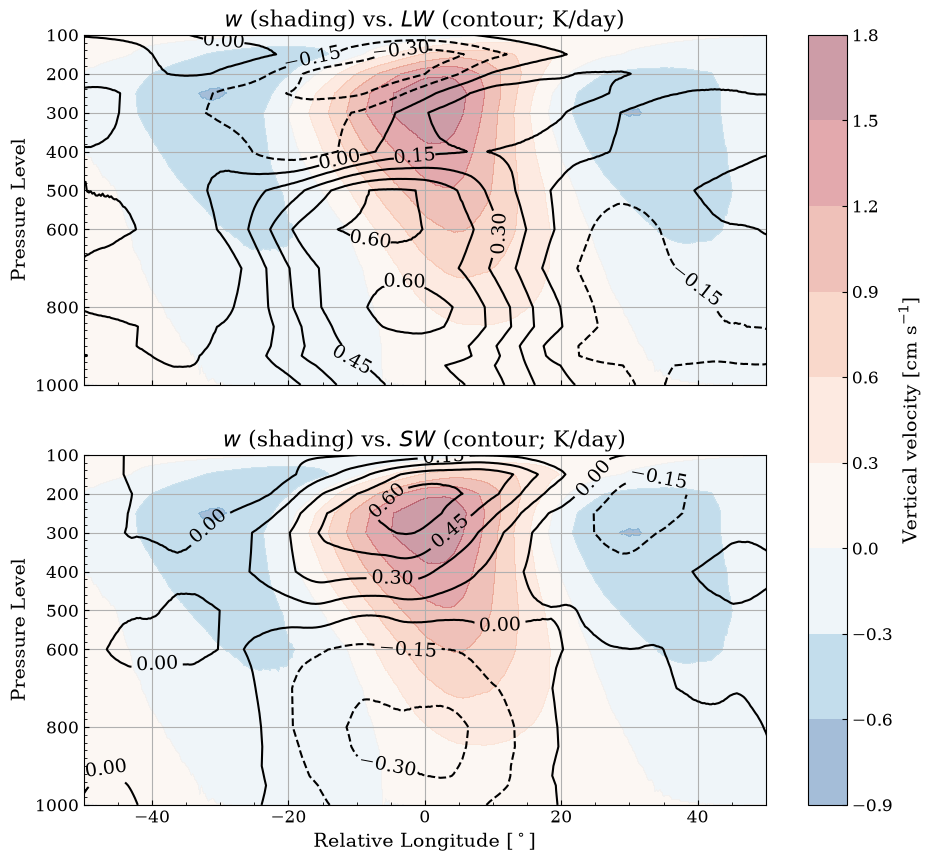

In [19]:

fig, axes = plt.subplots(2, 1, figsize=(11, 10), sharex="col")

ax1, ax2 = axes.flatten()

w_ctf = ax1.contourf(
    x_rel, plev,
    (w_composite - np.nanmean(w_composite, axis=1, keepdims=True)) * 1e2,
    cmap="RdBu_r",
    norm = TwoSlopeNorm(0.0),
    alpha=0.4
    )
LW_ct = ax1.contour(
    x_rel, plev,
    lw_smoothed - np.nanmean(lw_smoothed, axis=1, keepdims=True),
    colors="k"
    )
ax1.minorticks_on()
ax1.set_yticks([100, 200, 300, 400, 500, 600, 800, 1000])
ax1.set_yticklabels(["100", "200", "300", "400", "500", "600", "800", "1000"])
ax1.set_xlim(-50, 50)
ax1.set_ylim(1000, 100)
ax1.set_ylabel("Pressure Level")
ax1.set_title(r"$w$ (shading) vs. $LW$ (contour; K/day)")
ax1.grid()
plt.clabel(LW_ct, inline=True)

w_ctf = ax2.contourf(
    x_rel, plev,
    (w_composite - np.nanmean(w_composite, axis=1, keepdims=True)) * 1e2,
    cmap="RdBu_r",
    norm = TwoSlopeNorm(0.0),
    alpha=0.4
    )

SW_ct = ax2.contour(
    x_rel, plev,
    sw_smoothed - np.nanmean(sw_smoothed, axis=1, keepdims=True),
    colors="k"
    )
ax2.minorticks_on()
ax2.set_yticks([100, 200, 300, 400, 500, 600, 800, 1000])
ax2.set_yticklabels(["100", "200", "300", "400", "500", "600", "800", "1000"])
ax2.set_xlim(-50, 50)
ax2.set_xlabel(r"Relative Longitude [$^\circ$]")
ax2.set_ylim(1000, 100)
ax2.set_ylabel("Pressure Level")
ax2.set_title(r"$w$ (shading) vs. $SW$ (contour; K/day)")
ax2.grid()
fig.colorbar(w_ctf, ax=axes, label=r"Vertical velocity [cm s$^{-1}$]")
plt.clabel(SW_ct, inline=True)

plt.savefig("/home/b11209013/Manuscript_Prep/KW_CRI/Figure/LWSW_composite.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)
